## Rod Cantilever Example

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=0.01,
                          shell_h=0)

material = dismech.Material(density=1000,
                            youngs_rod=1e6,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-3,
                                  max_iter=25,
                                  total_time=1.0,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.80665]))

geo = dismech.Geometry.from_txt(
    '../tests/resources/rod_cantilever/horizontal_rod_n101.txt')

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

### Time Stepping

As we are performing a static simulation, we must change gravity for each time step.

In [2]:
fixed_points = np.array([0, 100])

robot = robot.fix_nodes(fixed_points)
stepper = dismech.NewmarkBetaTimeStepper(robot)

robots = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])

In [ ]:
t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
options = dismech.AnimationOptions(y_lim=[-0.01, 0.01],
                  title='Drooping Beam (N=101)', camera_view=(0,90))

fig = dismech.get_interactive_animation_plotly(robot, t, qs, options)
fig.show()

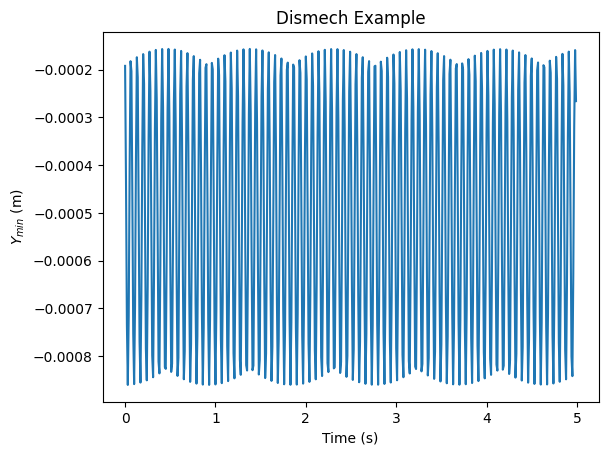

In [ ]:
import matplotlib.pyplot as plt

plt.title("Dismech Example")
plt.plot(t, np.min(qs, axis=1))
plt.xlabel("Time (s)")
plt.ylabel("$Y_{min}$ (m)")
plt.show()

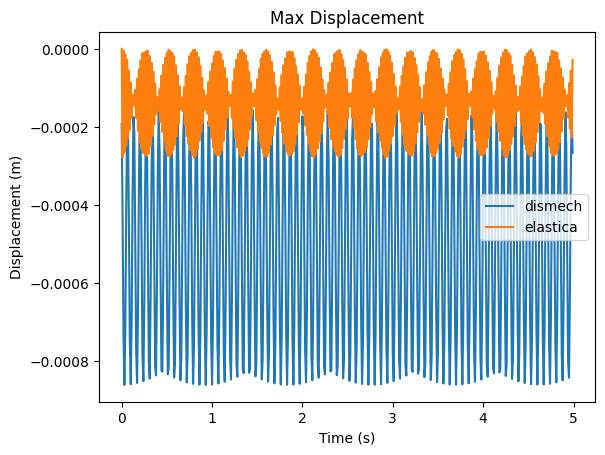

In [ ]:
elastica = np.load('elastica.npy')
plt.plot(t, np.min(qs[:, 2::3], 1), label='dismech')
plt.plot(t, elastica, label='elastica')
plt.title("Max Displacement")
plt.ylabel("Displacement (m)")
plt.xlabel("Time (s)")
plt.legend()
plt.show()